# App Inventory Signal Analysis

재고 검색/재고 상세 조회가 POS 판매 전 선행 관심 신호로 쓸 수 있는지 확인하는 노트북입니다.

- 입력: `data/processed/app_event_integrated/*.parquet`, `data/raw/app/상품코드목록_260416.csv`, `data/processed/B2_POS_SALE.parquet`
- 출력: `eda/app_event_yumi/outputs/inventory_signal_analysis/`
- 주의: 재고 이벤트에는 직접 상품 ID가 없어서, 상품 단위 분석은 `재고 검색어 -> 상품명 후보 매칭`으로만 가능합니다.

## 0. 환경 준비

분석 모듈을 불러오고 출력 폴더를 준비합니다.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

BASE_DIR = Path.cwd()
if not (BASE_DIR / "app_inventory_signal_analysis.py").exists():
    BASE_DIR = Path.cwd() / "eda" / "app_event_yumi"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

analysis = importlib.import_module("app_inventory_signal_analysis")
analysis = importlib.reload(analysis)

OUTPUT_DIR = analysis.OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR, OUTPUT_DIR

(PosixPath('/Users/yumi/Seven-eleven/eda/app_event_yumi'),
 PosixPath('/Users/yumi/Seven-eleven/eda/app_event_yumi/outputs/inventory_signal_analysis'))

## 1. 재고 이벤트 로드

`af_search_inventory`, `af_content_view_inventory`만 필터링하고 JSON 안의 `af_search_string`을 꺼냅니다.

In [2]:
lf = analysis.app_event_lf()
inv = analysis.inventory_lf(lf)
inv.collect_schema()

Schema([('Event Time', String),
        ('Event Name', String),
        ('Event Value', String),
        ('Media Source', String),
        ('Campaign', String),
        ('Platform', String),
        ('AppsFlyer ID', String),
        ('af_content', String),
        ('af_content_id', String),
        ('af_customer_user_id', String),
        ('pos_item_code', String),
        ('item_name', String),
        ('category_hierarchy', String),
        ('event_date', Date),
        ('event_month', String),
        ('event_hour', Int8),
        ('platform_norm', String),
        ('media_source_norm', String),
        ('inventory_search_string', String),
        ('is_abnormal_user', Boolean)])

## 2. 재고 이벤트 로깅 품질

상품 ID가 있는지, 검색어가 있는지, placeholder 사용자 비중이 어느 정도인지 확인합니다.

In [3]:
summary = analysis.collect_inventory_event_summary(inv)
analysis.save_csv(summary, "inventory_event_summary.csv")
summary

Event Name,event_count,unique_users,abnormal_user_events,search_string_rows,af_content_id_rows,af_content_rows,search_string_coverage_pct,af_content_id_coverage_pct,abnormal_user_event_pct
str,u32,u32,u32,u32,u32,u32,f64,f64,f64
"""af_search_inventory""",2646992,137488,1054497,2646992,0,0,100.0,0.0,39.8376
"""af_content_view_inventory""",2146290,141219,873918,0,0,2146290,0.0,0.0,40.7176


## 3. 일자별 재고 퍼널

일자별 재고 검색과 재고 상세 조회 규모를 보고, `상세 조회 / 검색` 비율을 확인합니다.

In [4]:
daily_funnel = analysis.collect_daily_inventory_funnel(inv)
analysis.save_csv(daily_funnel, "daily_inventory_funnel.csv")
daily_funnel.head(20)

event_date,event_count_af_search_inventory,event_count_af_content_view_inventory,clean_unique_users_af_search_inventory,clean_unique_users_af_content_view_inventory,inventory_view_per_100_searches
date,u32,u32,u32,u32,f64
2025-03-01,28596,16627,5742,5742,58.1445
2025-03-02,22474,13492,5125,5098,60.0338
2025-03-03,18312,11495,4573,4639,62.773
2025-03-04,17920,11979,4950,5130,66.8471
2025-03-05,18476,12306,5068,5213,66.6053
…,…,…,…,…,…
2025-03-16,12772,9176,3642,3752,71.8447
2025-03-17,12875,9485,3745,3889,73.6699
2025-03-18,13994,9826,4039,4176,70.2158


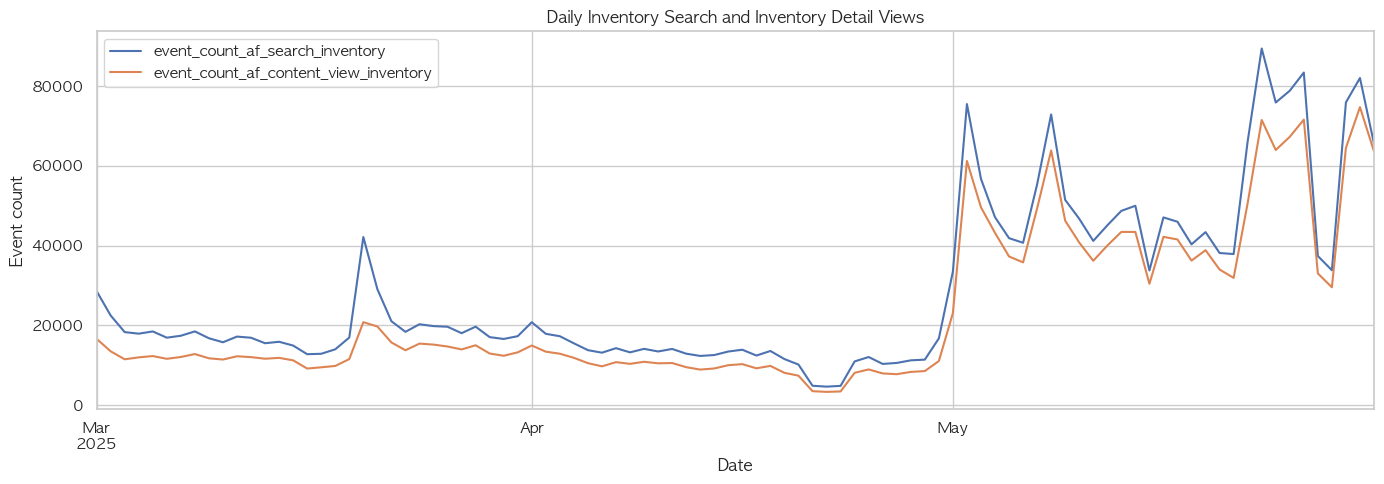

In [5]:
daily_funnel_pd = daily_funnel.to_pandas()
ax = daily_funnel_pd.plot(
    x="event_date",
    y=["event_count_af_search_inventory", "event_count_af_content_view_inventory"],
    figsize=(14, 5),
)
ax.set_title("Daily Inventory Search and Inventory Detail Views")
ax.set_xlabel("Date")
ax.set_ylabel("Event count")
plt.tight_layout()
plt.show()

## 4. 재고 검색어 랭킹

비정상 사용자 `L00000000000`을 제외하고 재고 검색어를 집계합니다. 이 검색어가 상품 후보 매칭의 출발점입니다.

In [6]:
search_terms = analysis.collect_search_terms(inv)
analysis.save_csv(search_terms, "inventory_search_terms.csv")
analysis.save_csv(search_terms.head(200), "top200_inventory_search_terms.csv")
search_terms.head(50)

inventory_search_string,search_string_norm,search_count,unique_users,first_search_date,last_search_date
str,str,u32,u32,date,date
"""자이언츠""","""자이언츠""",447842,29358,2025-03-20,2025-05-31
"""KBO""","""kbo""",172946,29991,2025-03-01,2025-05-31
"""블랙서클위스키""","""블랙서클위스키""",86126,15204,2025-03-01,2025-05-31
"""콜렉션카드""","""콜렉션카드""",51542,6360,2025-03-01,2025-05-31
"""롯데자이언츠""","""롯데자이언츠""",36417,10025,2025-03-20,2025-05-31
…,…,…,…,…,…
"""팅클""","""팅클""",2371,1340,2025-04-21,2025-05-31
"""생드래프트""","""생드래프트""",2266,1069,2025-03-01,2025-05-31
"""오이스터베이""","""오이스터베이""",2248,929,2025-03-02,2025-05-31


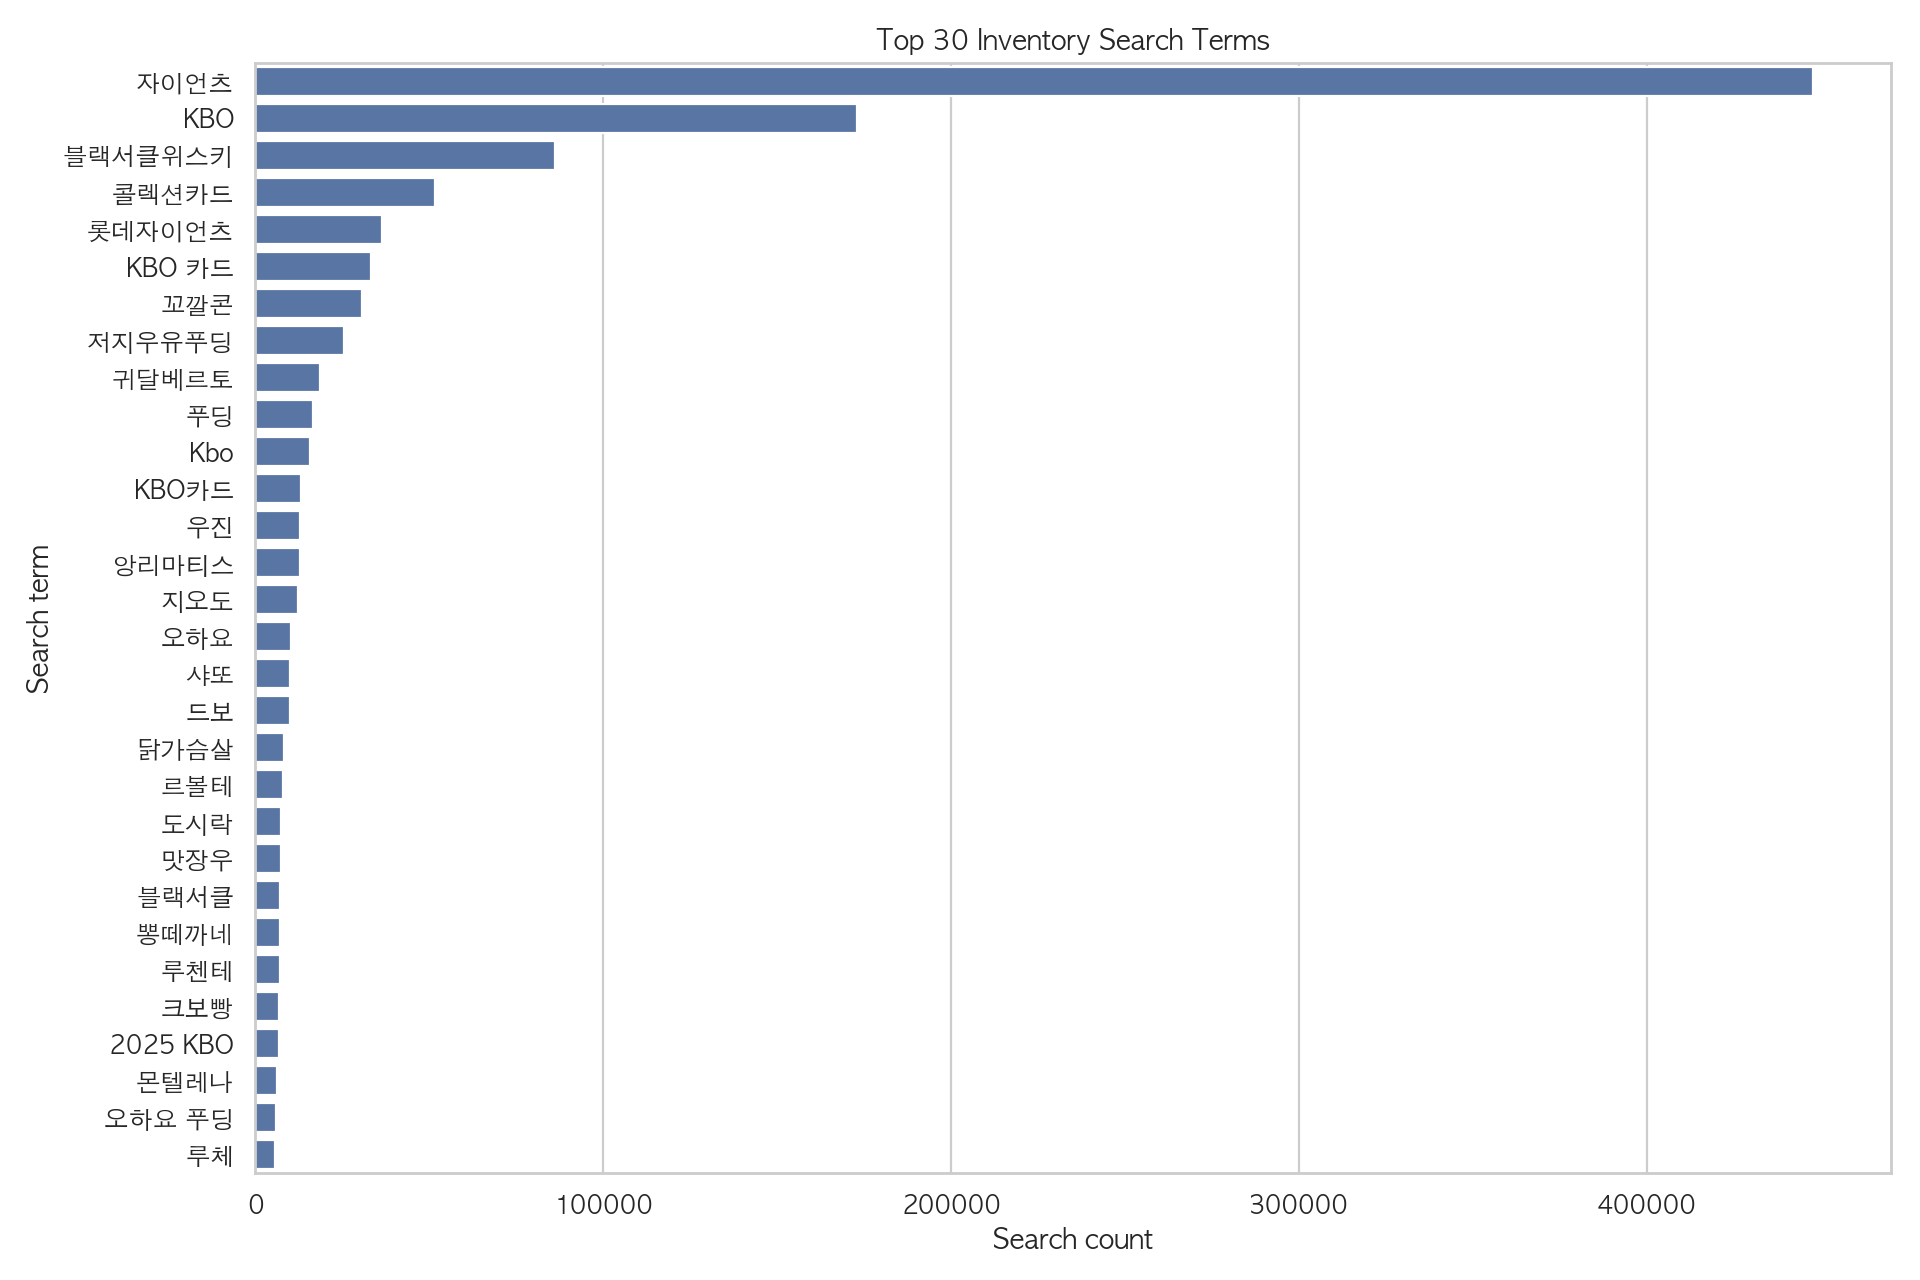

In [7]:
analysis.save_barplot(
    search_terms.head(30),
    x="search_count",
    y="inventory_search_string",
    title="Top 30 Inventory Search Terms",
    xlabel="Search count",
    ylabel="Search term",
    filename="top30_inventory_search_terms.png",
)
display(Image(filename=str(OUTPUT_DIR / "top30_inventory_search_terms.png")))

## 5. 검색어-상품명 후보 매칭

상위 검색어를 상품명과 보수적으로 매칭합니다. `match_type`, `match_score`를 반드시 같이 확인해야 합니다.

In [8]:
mapping = analysis.load_mapping()
candidates = analysis.match_search_terms_to_products(search_terms, mapping)
best_matches = analysis.best_product_matches(candidates)

analysis.save_csv(candidates, "inventory_search_product_candidates.csv")
analysis.save_csv(best_matches, "inventory_search_best_product_matches.csv")

best_matches.head(50)

search_string_norm,inventory_search_string,mapped_pos_item_code,mapped_item_name,mapped_category_hierarchy,category_l,category_m,match_type,match_score,search_count,unique_users
str,str,str,str,str,str,str,str,i64,u32,u32
"""자이언츠""","""자이언츠""","""125416""","""자이언츠)마!비어라500ml캔""","""맥주>국산맥주>캔맥주(중)""","""맥주""","""국산맥주""","""item_startswith_search""",90,447842,29358
"""kbo""","""KBO""","""128207""","""KBO)2025프로야구콜렉션카드플러스""","""문구/완구>일반완구>일반완구""","""문구/완구""","""일반완구""","""item_startswith_search""",90,172946,29991
"""블랙서클위스키""","""블랙서클위스키""","""123923""","""신동엽)블랙서클위스키700ml""","""양주와인>양주>위스키""","""양주와인""","""양주""","""search_in_item""",80,86126,15204
"""콜렉션카드""","""콜렉션카드""","""128207""","""KBO)2025프로야구콜렉션카드플러스""","""문구/완구>일반완구>일반완구""","""문구/완구""","""일반완구""","""search_in_item""",80,51542,6360
"""롯데자이언츠""","""롯데자이언츠""","""125340""","""KBO)롯데자이언츠거인단팥빵100g""","""빵>간식빵>캐릭터빵""","""빵""","""간식빵""","""search_in_item""",80,36417,10025
…,…,…,…,…,…,…,…,…,…,…
"""모찌""","""모찌""","""128203""","""G)마루짱모찌우동109g""","""면>용기면>라면(소형컵)""","""면""","""용기면""","""search_in_item""",80,1938,816
"""씨앗""","""씨앗""","""125435""","""KBO)롯데자이언츠씨앗호떡빵97g""","""빵>간식빵>캐릭터빵""","""빵""","""간식빵""","""search_in_item""",80,1915,598
"""지오도bdm""","""지오도 bdm""","""124510""","""우진)지오도BDM 18""","""양주와인>와인>레드""","""양주와인""","""와인""","""search_in_item""",80,1859,747


## 6. 매칭 커버리지

상위 검색어 중 상품 후보로 연결된 비중을 확인합니다. 커버리지가 낮으면 재고 검색은 상품 단위보다 키워드/콘텐츠 단위로 쓰는 편이 안전합니다.

In [9]:
top_terms = search_terms.head(analysis.DEFAULT_TOP_TERMS)
coverage = top_terms.select(
    [
        analysis.pl.len().alias("top_search_terms"),
        analysis.pl.col("search_count").sum().alias("top_term_searches"),
    ]
).with_columns(
    [
        analysis.pl.lit(best_matches.height).alias("matched_terms"),
        analysis.pl.lit(best_matches["search_count"].sum() if not best_matches.is_empty() else 0).alias(
            "matched_term_searches"
        ),
    ]
).with_columns(
    [
        (analysis.pl.col("matched_terms") / analysis.pl.col("top_search_terms") * 100).round(4).alias(
            "matched_term_pct"
        ),
        (analysis.pl.col("matched_term_searches") / analysis.pl.col("top_term_searches") * 100).round(4).alias(
            "matched_search_pct"
        ),
    ]
)
coverage

top_search_terms,top_term_searches,matched_terms,matched_term_searches,matched_term_pct,matched_search_pct
u32,u32,i32,i32,f64,f64
500,1379167,419,1271280,83.8,92.1774


## 7. 상품 후보별 일자 재고 검색량

매칭된 검색어를 상품 후보 단위로 일자별 집계합니다.

In [10]:
daily_search_terms = analysis.collect_daily_search_terms(inv, search_terms.head(analysis.DEFAULT_TOP_TERMS))
matched_daily_searches = analysis.collect_matched_daily_searches(daily_search_terms, best_matches)

analysis.save_csv(daily_search_terms, "daily_top_inventory_search_terms.csv")
analysis.save_csv(matched_daily_searches, "daily_inventory_searches_matched_products.csv")

matched_daily_searches.head(50)

event_date,mapped_pos_item_code,mapped_item_name,category_l,category_m,match_type,match_score,inventory_search_count,inventory_search_users,representative_search_string
date,str,str,str,str,str,i64,u32,u32,str
2025-03-01,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,1,1,"""11찬"""
2025-03-03,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,1,1,"""11찬"""
2025-03-04,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,2,2,"""11찬"""
2025-03-05,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,3,2,"""11찬"""
2025-03-06,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,2,1,"""11찬"""
…,…,…,…,…,…,…,…,…,…
2025-04-18,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,1,1,"""11찬"""
2025-04-27,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,1,1,"""11찬"""
2025-04-28,"""012679""","""11찬 도시락""","""미반""","""도시락""","""item_startswith_search""",90,1,1,"""11찬"""


## 8. POS 판매와 연결

매칭된 상품 후보만 POS에서 일자별 판매량을 집계합니다. 원천 POS parquet은 읽기만 합니다.

In [11]:
if matched_daily_searches.is_empty():
    pos_daily_sales = analysis.pl.DataFrame()
else:
    start_date = matched_daily_searches["event_date"].min()
    end_date = matched_daily_searches["event_date"].max()
    product_codes = matched_daily_searches["mapped_pos_item_code"].unique().to_list()
    pos_daily_sales = analysis.collect_pos_daily_sales(product_codes, start_date, end_date)

analysis.save_csv(pos_daily_sales, "pos_daily_sales_for_inventory_matched_products.csv")
pos_daily_sales.head(50)

event_date,mapped_pos_item_code,pos_sales_qty,pos_sales_amount,pos_receipts
date,str,i64,i64,u32
2025-03-12,"""012679""",1,6300,1
2025-03-18,"""012679""",1,6300,1
2025-03-23,"""012679""",4,25200,2
2025-03-28,"""012679""",1,6300,1
2025-03-30,"""012679""",1,6300,1
…,…,…,…,…
2025-03-27,"""014071""",384,456504,389
2025-03-28,"""014071""",376,450018,374
2025-03-29,"""014071""",302,360199,304


## 9. Lead-Lag 상관 확인

`lag_days=1`은 오늘 재고 검색량과 내일 POS 판매량의 상관입니다. 상품명 후보 매칭 기반이므로, 높은 상관은 추가 검증 후보로 해석합니다.

In [12]:
lead_lag = analysis.collect_lead_lag_correlations(matched_daily_searches, pos_daily_sales)
analysis.save_csv(lead_lag, "inventory_search_pos_lead_lag_correlations.csv")
if not lead_lag.is_empty():
    analysis.save_csv(
        lead_lag.filter(analysis.pl.col("lag_days") > 0).head(100),
        "top100_positive_lag_inventory_search_pos_correlations.csv",
    )
lead_lag.head(50)

mapped_pos_item_code,mapped_item_name,category_l,category_m,lag_days,paired_days,total_searches,total_sales_qty,search_sales_qty_corr,user_sales_qty_corr
str,str,str,str,i32,u32,u32,i64,f64,f64
"""124510""","""우진)지오도BDM 18""","""양주와인""","""와인""",0,18,18963,174,0.97368,0.96817
"""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",0,45,7695,390,0.95377,0.94536
"""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",1,44,7612,334,0.9395,0.94169
"""125474""","""우진)샤또꾸떼16""","""양주와인""","""와인""",0,22,5022,145,0.93531,0.93227
"""125044""","""농협)25년 감사장 한송이카네이션""","""서비스 상품""","""기타""",0,14,154,123,0.93252,0.96536
…,…,…,…,…,…,…,…,…,…
"""124510""","""우진)지오도BDM 18""","""양주와인""","""와인""",4,14,17478,76,0.73892,0.7773
"""124683""","""KBO)삼립SSG랜더스소금버터우주선빵85g""","""빵""","""간식빵""",4,32,222,5803,0.73601,0.72795
"""108365""","""우진)지오도라퀸타20/21 750ml""","""양주와인""","""와인""",5,28,1171,130,0.7338,0.73064


## 10. 선행 신호 후보만 보기

당일 상관보다 `lag_days > 0`에서 높게 나오는 상품을 우선 검토합니다. `paired_days`, `total_searches`, `total_sales_qty`가 너무 작으면 제외하는 것이 좋습니다.

In [13]:
lead_candidates = (
    lead_lag.filter(
        (analysis.pl.col("lag_days") > 0)
        & (analysis.pl.col("paired_days") >= 14)
        & (analysis.pl.col("total_searches") >= 100)
        & (analysis.pl.col("total_sales_qty") >= 50)
    )
    .sort(["search_sales_qty_corr", "total_searches"], descending=[True, True])
)
lead_candidates.head(50)

mapped_pos_item_code,mapped_item_name,category_l,category_m,lag_days,paired_days,total_searches,total_sales_qty,search_sales_qty_corr,user_sales_qty_corr
str,str,str,str,i32,u32,u32,i64,f64,f64
"""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",1,44,7612,334,0.9395,0.94169
"""124513""","""우진)루체 21 750ml""","""양주와인""","""와인""",3,21,5589,70,0.92996,0.91943
"""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",2,43,7517,293,0.92429,0.93052
"""124513""","""우진)루체 21 750ml""","""양주와인""","""와인""",1,23,5728,104,0.92346,0.93745
"""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",3,41,7438,261,0.91123,0.90637
…,…,…,…,…,…,…,…,…,…
"""132835""","""PB)#대파열라면큰컵""","""면""","""용기면""",3,64,186,5161,0.68165,0.69528
"""191572""","""롯데)일그리지오끼안티750ml""","""양주와인""","""와인""",9,36,899,88,0.67962,0.65989
"""108364""","""우진)루첸테 750ml""","""양주와인""","""와인""",4,34,6397,227,0.67884,0.6843


## 11. 특정 상품 시계열 확인

위 후보 중 하나를 골라 재고 검색량과 POS 판매량을 같은 날짜 축에서 확인합니다.

/var/folders/2q/px9cmz3n3ll50_r9dk1tq9440000gn/T/ipykernel_10634/248396556.py:9: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  .join(


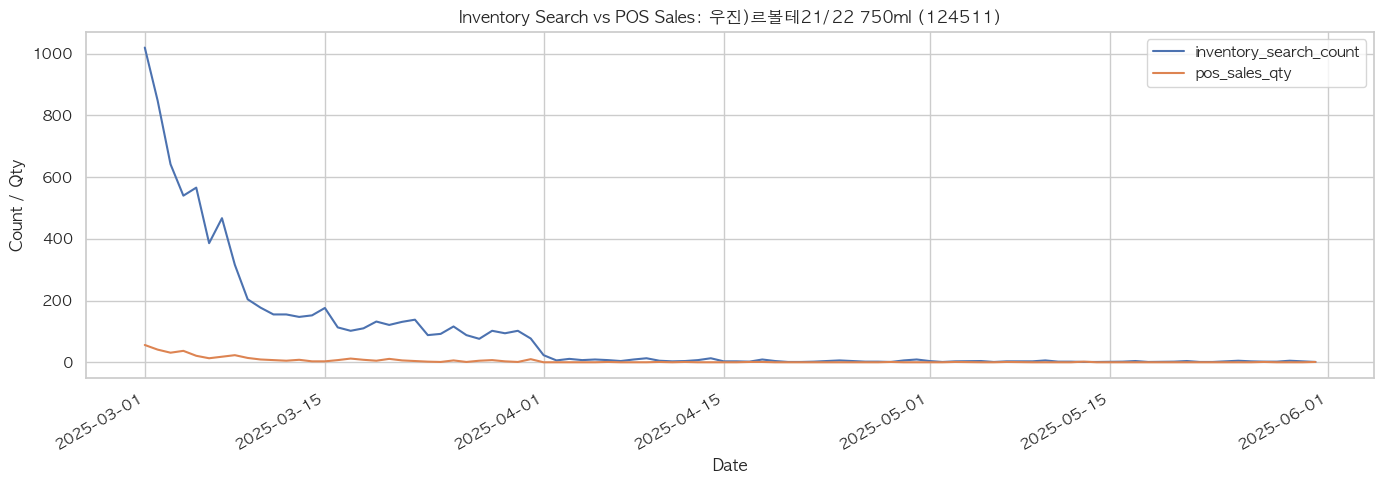

In [14]:
if lead_candidates.is_empty():
    print("No lead candidates after filters.")
else:
    selected_code = lead_candidates.item(0, "mapped_pos_item_code")
    selected_name = lead_candidates.item(0, "mapped_item_name")
    ts = (
        matched_daily_searches.filter(analysis.pl.col("mapped_pos_item_code") == selected_code)
        .select(["event_date", "inventory_search_count"])
        .join(
            pos_daily_sales.filter(analysis.pl.col("mapped_pos_item_code") == selected_code).select(
                ["event_date", "pos_sales_qty"]
            ),
            on="event_date",
            how="outer",
            coalesce=True,
        )
        .fill_null(0)
        .sort("event_date")
        .to_pandas()
    )
    ax = ts.plot(x="event_date", y=["inventory_search_count", "pos_sales_qty"], figsize=(14, 5))
    ax.set_title(f"Inventory Search vs POS Sales: {selected_name} ({selected_code})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count / Qty")
    plt.tight_layout()
    plt.show()

## 12. 해석 메모

현재 로그 기준으로는 재고 상세 조회 이벤트에 상품 ID가 없습니다. 따라서 가장 확실한 다음 개선점은 앱 로그에 `af_content_id` 또는 POS 상품코드, 점포코드를 재고 상세 조회 이벤트에도 남기는 것입니다. 그 전까지는 재고 검색어 기반 후보 매칭으로 선행 신호 가능성을 탐색하는 수준이 안전합니다.

1. 재고 기능은 “탐색”보다 “목적 검색”에 가깝다

af_search_inventory가 264만 건, af_content_view_inventory가 214만 건이고, 검색 대비 상세 조회 비율이 약 81%입니다.
이 정도면 사용자가 그냥 둘러보는 것이 아니라, “이 상품이 있는지 확인하려는 목적”으로 재고 기능을 쓰고 있다고 보는 게 자연스럽습니다.

즉 재고 검색은 단순 앱 사용량 지표가 아니라 구매 전 의도 신호로 볼 만합니다.

2. 다만 현재 로그는 상품 단위 분석에 한계가 크다

가장 중요한 제약은 재고 이벤트에 직접 상품 ID가 없다는 점입니다.

af_search_inventory: af_search_string만 있음
af_content_view_inventory: af_content_id 없음
점포코드도 없음
그래서 현재는 “사용자가 어떤 상품의 재고를 봤는지”를 확정할 수 없습니다.
이번 분석은 검색어를 상품명에 매칭한 후보 분석이므로, 결과는 확정 매출 기여 분석이 아니라 선행 신호 후보 발굴로 해석해야 합니다.

3. 검색어 상위권은 신제품/한정판/콜라보 성격이 강하다

상위 검색어가 자이언츠, KBO, 블랙서클위스키, 콜렉션카드, 롯데자이언츠, 꼬깔콘, 저지우유푸딩 등입니다.

이건 재고 기능이 일반 생필품보다 다음 유형에서 강하게 쓰인다는 뜻입니다.

한정판
콜라보/IP 상품
주류/희소 상품
신상품
앱/커뮤니티에서 화제가 된 상품
즉 재고 검색량은 특히 희소성 있는 상품의 수요 압력을 잘 포착할 가능성이 큽니다.

4. 일부 상품은 POS 판매와 강한 lead-lag 신호가 보인다

검색어-상품 후보 매칭 후 POS 판매와 비교했을 때, 일부 상품에서 lag_days > 0 상관이 높게 나왔습니다.

예:

우진)르볼테21/22 750ml
lag_days=1
paired_days=44
total_searches=7,612
total_sales_qty=334
검색량-POS판매량 상관 0.9395
이건 “오늘 재고 검색이 늘어난 상품이 내일 판매도 늘어나는” 패턴 후보입니다.
특히 와인/주류 쪽 후보가 많이 잡힌 점은, 재고 확인 후 방문 구매로 이어지는 행동과 잘 맞습니다.

5. 재고 검색은 전체 상품보다 특정 상품군에서 더 강한 예측 변수일 가능성이 크다

모든 상품에 동일하게 적용하기보다, 아래 상품군에서 먼저 feature로 쓰는 게 좋아 보입니다.

주류/와인/위스키
콜라보 상품
KBO/IP 상품
디저트/푸딩류
편의점 화제 상품
재고 품절 가능성이 높은 상품
반대로 상시 판매 생필품이나 검색어가 모호한 상품은 노이즈가 클 수 있습니다.

6. 모델링 관점에서는 “재고 검색량”을 상품 관심도 feature로 추가할 가치가 있다

HIN/GNN 또는 신제품 예측 feature로는 아래 형태가 좋아 보입니다.

상품별 일자 재고 검색량
상품별 재고 검색 사용자 수
최근 1일/3일/7일 누적 재고 검색량
전주 대비 재고 검색 증가율
검색량 대비 POS 판매량 lag correlation
검색 급증 후 판매 발생 여부
검색어-상품 매칭 신뢰도
특히 신제품 예측에서는 단순 조회보다 재고 검색이 더 강한 신호일 수 있습니다.
상품 페이지 조회는 노출 효과가 섞이지만, 재고 검색은 사용자가 직접 입력한 행동이라 의도가 더 강합니다.

7. 다음 액션은 두 갈래입니다

분석 측면:

현재 만든 inventory_search_pos_lead_lag_correlations.csv에서 lag_days > 0, paired_days >= 14, total_searches >= 100, total_sales_qty >= 50 조건으로 후보를 선별
후보 상품의 시계열을 눈으로 확인
당일 상관보다 1~3일 lag에서 더 높은 상품을 우선 선행 신호 후보로 분류
로그 개선 측면:

af_content_view_inventory에 af_content_id 또는 POS 상품코드 추가
재고 조회 점포코드 추가
검색 결과 클릭 상품 ID 추가
품절 여부/재고 수량 구간 추가
이게 들어오면 “재고 검색어 후보 분석”이 아니라 진짜로 상품-점포-일자 단위 수요 선행지표를 만들 수 있습니다.

요약하면, 현재 데이터만으로도 재고 기능은 신제품/희소 상품의 선행 관심 신호로 꽤 유망합니다. 다만 상품 ID가 빠져 있어서 지금은 후보 발굴 단계이고, 로그가 보강되면 POS 판매 예측 feature로 바로 승격할 수 있는 상태입니다.





